100%|██████████| 9.91M/9.91M [00:00<00:00, 17.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.84MB/s]


Adam Epoch 1 | Loss: 12.6524 | Acc: 0.9926
Adam Epoch 2 | Loss: 1.7262 | Acc: 0.9989
Adam Epoch 3 | Loss: 1.2610 | Acc: 0.9988
Adam Epoch 4 | Loss: 1.0586 | Acc: 0.9990
Adam Epoch 5 | Loss: 0.7015 | Acc: 0.9996
SGD Epoch 1 | Loss: 146.2778 | Acc: 0.9317
SGD Epoch 2 | Loss: 13.0669 | Acc: 0.9921
SGD Epoch 3 | Loss: 7.9088 | Acc: 0.9943
SGD Epoch 4 | Loss: 5.8610 | Acc: 0.9957
SGD Epoch 5 | Loss: 4.5940 | Acc: 0.9967


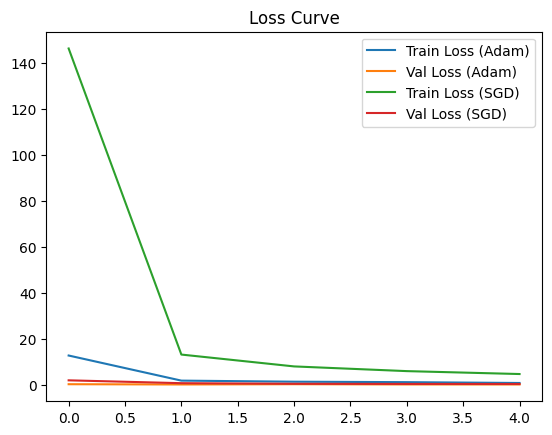

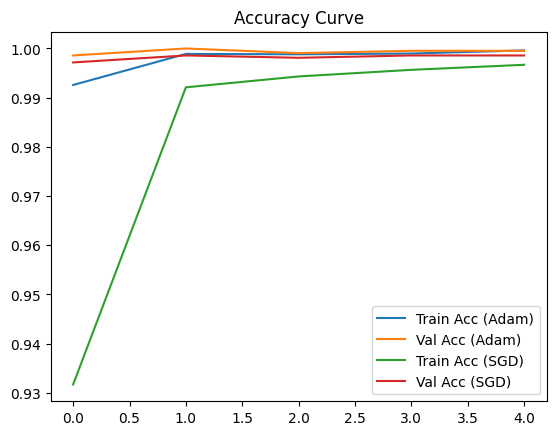


===== Final Results =====
Adam Accuracy: 99.95%
SGD Accuracy: 99.86%


In [ ]:
# =========================
# 1) Imports
# =========================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

# =========================
# 2) Load Dataset (MNIST)
# =========================
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)


def filter_dataset(dataset):
    indices = [i for i, (_, y) in enumerate(dataset) if y in [0,1]]
    return Subset(dataset, indices)

train_dataset = filter_dataset(train_dataset)
test_dataset = filter_dataset(test_dataset)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# =========================
# 3) CNN Model
# =========================
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32*7*7, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

# =========================
# 4) Training
# =========================
def train_model(optimizer_name):
    model = SimpleCNN()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    else:
        optimizer = optim.SGD(model.parameters(), lr=0.01)

    criterion = nn.BCEWithLogitsLoss()

    train_losses, train_accs = [], []
    val_losses, val_accs = [], []

    for epoch in range(5):
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for imgs, labels in train_loader:
            labels = labels.float().unsqueeze(1)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds.squeeze().int() == labels.squeeze().int()).sum().item()
            total += labels.size(0)

        train_losses.append(total_loss)
        train_accs.append(correct/total)

        # Validation
        model.eval()
        v_loss = 0
        v_correct = 0
        v_total = 0

        with torch.no_grad():
            for imgs, labels in test_loader:
                labels = labels.float().unsqueeze(1)
                outputs = model(imgs)

                loss = criterion(outputs, labels)
                v_loss += loss.item()

                preds = torch.sigmoid(outputs) > 0.5
                v_correct += (preds.squeeze().int() == labels.squeeze().int()).sum().item()
                v_total += labels.size(0)

        val_losses.append(v_loss)
        val_accs.append(v_correct/v_total)

        print(f"{optimizer_name} Epoch {epoch+1} | Loss: {total_loss:.4f} | Acc: {correct/total:.4f}")

    return model, train_losses, train_accs, val_losses, val_accs, v_correct/v_total

# =========================
# 5) Experiments
# =========================
model_adam, tl1, ta1, vl1, va1, acc_adam = train_model("Adam")
model_sgd, tl2, ta2, vl2, va2, acc_sgd = train_model("SGD")

# =========================
# 6) Visualization
# =========================
plt.plot(tl1, label="Train Loss (Adam)")
plt.plot(vl1, label="Val Loss (Adam)")
plt.plot(tl2, label="Train Loss (SGD)")
plt.plot(vl2, label="Val Loss (SGD)")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(ta1, label="Train Acc (Adam)")
plt.plot(va1, label="Val Acc (Adam)")
plt.plot(ta2, label="Train Acc (SGD)")
plt.plot(va2, label="Val Acc (SGD)")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

# =========================
# 7) Results
# =========================
print("\n===== Final Results =====")
print(f"Adam Accuracy: {acc_adam*100:.2f}%")
print(f"SGD Accuracy: {acc_sgd*100:.2f}%")